In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt



In [2]:
def generate_interevent_histogram(data_file_path, exclude_events, low_filter, high_filter):
    events = pd.read_csv(f"{data_file_path}")

    events_excluded = events[~events["Type"].isin(exclude_events)]

    interevent_time = events_excluded['frame'] - events_excluded.shift(1)['frame']

    interevent_time_list = interevent_time.to_numpy()[1:]

    interevent_time_list = interevent_time_list[interevent_time_list >= low_filter]
    interevent_time_list = interevent_time_list[interevent_time_list <= high_filter]

    sns.kdeplot(interevent_time_list)
    plt.xlim(low_filter)

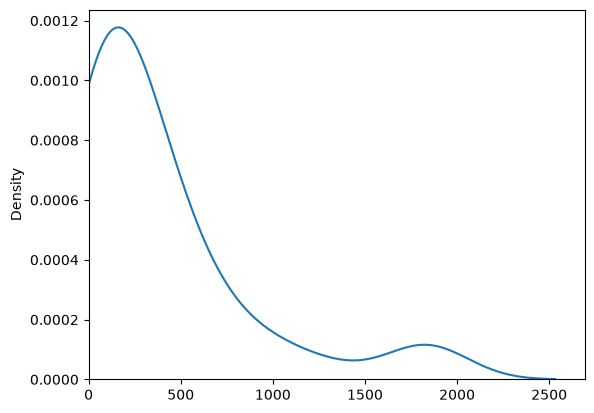

In [3]:
generate_interevent_histogram("./data/raw/M1_events.csv", exclude_events=['nest_entry', 'centre_entry'], low_filter=0, high_filter=2000)

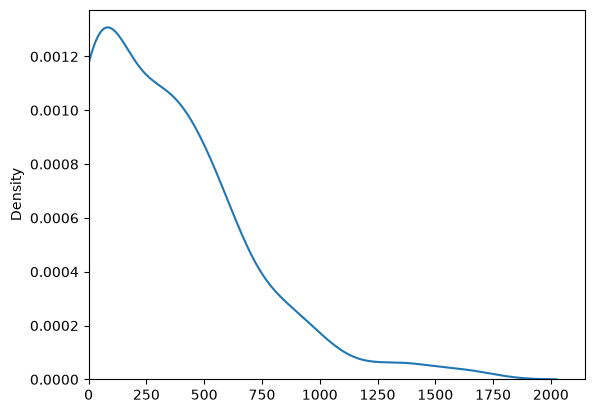

In [4]:
generate_interevent_histogram("./data/raw/M2_events.csv", exclude_events=['nest_entry', 'centre_entry'], low_filter=0, high_filter=2000)

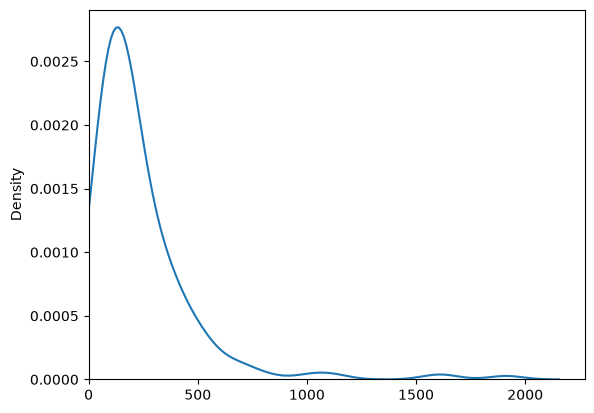

In [5]:
generate_interevent_histogram("./data/raw/g12_events.csv", exclude_events=['leave_nest', 'block_start', 'imaging_start', 'enter_feed', 'exit_feed', 'enter_drink','exit_drink', 'block_end', 'imaging_stop', 'block_available',
'enter_run', 'exit_run','enter_explore', 'exit_explore'], low_filter=0, high_filter=2000)

In [6]:
g12_events = pd.read_csv(f"./data/raw/g12_events.csv")

g12_events["Type"].unique()

<StringArray>
[     'leave_nest',     'block_start',   'imaging_start',      'enter_feed',
 'retrieve_pellet',       'exit_feed',     'enter_drink',           'drink',
      'exit_drink',       'block_end',    'imaging_stop', 'block_available',
    'enter_social',     'exit_social',       'enter_run',        'exit_run',
             'run',   'enter_explore',    'exit_explore']
Length: 19, dtype: str

In [7]:
M1_events = pd.read_csv(f"./data/raw/M1_events.csv")

M1_events["Type"].unique()

<StringArray>
[        'nest_entry',       'centre_entry',          'eat_start',
        'drink_start',  'social_long_start',         'eat3_start',
 'social_short_start']
Length: 7, dtype: str

In [8]:
M1_events 

,Date_Time,Type,frame
0,01/01/2026 0:00:00 PM,nest_entry,94
1,01/01/2026 0:00:00 PM,nest_entry,100
2,01/01/2026 0:00:00 PM,nest_entry,105
3,01/01/2026 0:00:00 PM,centre_entry,107
4,01/01/2026 0:00:00 PM,centre_entry,166
...,...,...,...
389,01/01/2026 0:00:00 PM,centre_entry,35230
390,01/01/2026 0:00:00 PM,nest_entry,35264
391,01/01/2026 0:00:00 PM,nest_entry,35285
392,01/01/2026 0:00:00 PM,centre_entry,35668


In [9]:
interevent_time = M1_events["frame"] - M1_events.shift(1)["frame"]

In [10]:
interevent_time_list = np.array(interevent_time.to_list()[1:])

interevent_time_list = interevent_time_list[interevent_time_list < 1000]

In [11]:
np.unique(interevent_time_list, return_counts=True)

(array([  0.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
         12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
         23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
         34.,  35.,  36.,  37.,  39.,  40.,  41.,  43.,  45.,  46.,  48.,
         49.,  50.,  51.,  52.,  53.,  54.,  56.,  57.,  58.,  59.,  61.,
         62.,  63.,  64.,  68.,  71.,  72.,  73.,  74.,  75.,  76.,  79.,
         82.,  83.,  85.,  87.,  88.,  90.,  91.,  93.,  94.,  98., 100.,
        102., 107., 108., 109., 112., 113., 115., 116., 119., 120., 121.,
        128., 132., 138., 142., 143., 144., 151., 154., 160., 164., 169.,
        174., 181., 193., 206., 259., 341., 383., 387., 471., 515., 645.,
        688., 823., 840., 854., 965.]),
 array([ 5,  7, 18, 15, 20, 26, 21, 16,  9, 15,  3,  5,  4,  7, 11,  7,  4,
        10,  3,  7,  6,  6,  2,  1,  3,  3,  5,  7,  4,  4,  2,  2,  5,  4,
         2,  3,  2,  3,  3,  1,  4,  3,  2,  3,  1,  2,  2,  2,  1, 

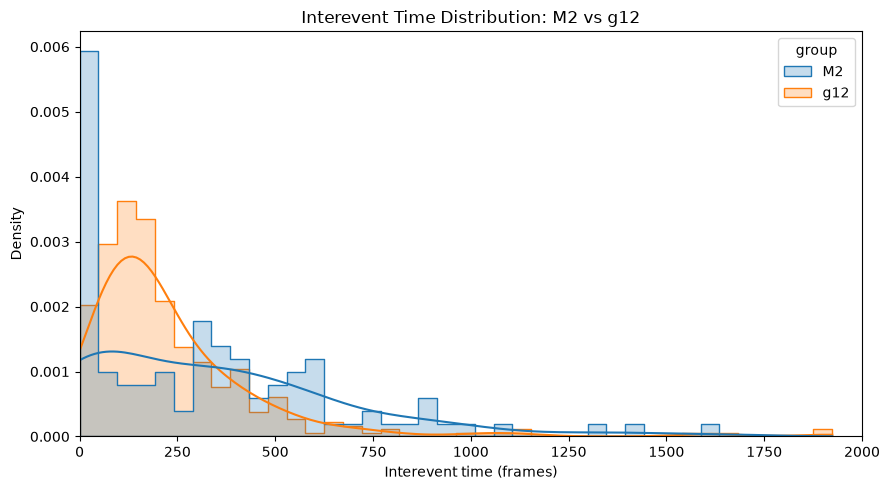

In [12]:
def get_interevent_times(data_file_path, exclude_events, low_filter=0, high_filter=2000):
    events = pd.read_csv(data_file_path)
    events = events[~events["Type"].isin(exclude_events)]

    interevent = events["frame"] - events.shift(1)["frame"]
    interevent = interevent.to_numpy()[1:]
    interevent = interevent[(interevent >= low_filter) & (interevent <= high_filter)]
    return interevent


m2_interevent = get_interevent_times(
    "./data/raw/M2_events.csv",
    exclude_events=["nest_entry", "centre_entry"],
    low_filter=0,
    high_filter=2000,
)

g12_interevent = get_interevent_times(
    "./data/raw/g12_events.csv",
    exclude_events=[
        "leave_nest", "block_start", "imaging_start", "enter_feed", "exit_feed",
        "enter_drink", "exit_drink", "block_end", "imaging_stop", "block_available",
        "enter_run", "exit_run", "enter_explore", "exit_explore"
    ],
    low_filter=0,
    high_filter=2000,
)

plot_df = pd.DataFrame({
    "interevent_time": np.concatenate([m2_interevent, g12_interevent]),
    "group": (["M2"] * len(m2_interevent)) + (["g12"] * len(g12_interevent)),
})

plt.figure(figsize=(9, 5))
sns.histplot(
    data=plot_df,
    x="interevent_time",
    hue="group",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.25,
    kde=True,
)
plt.xlim(0, 2000)
plt.xlabel("Interevent time (frames)")
plt.ylabel("Density")
plt.title("Interevent Time Distribution: M2 vs g12")
plt.tight_layout()
plt.show()